# Ploting

In [82]:
import pandas as pd
import numpy as np
import plotnine
from plotnine import ggplot, aes, geom_point, scale_x_log10, facet_grid, theme, stat_smooth, labs, element_text, theme_minimal

In [38]:
df = pd.read_table('Datasets/gapminder.tsv')
dfMap = df[df['year'].isin([1997, 2007])]

-----

We initiate a ggplot object loaded with the data. It generates an empty slot

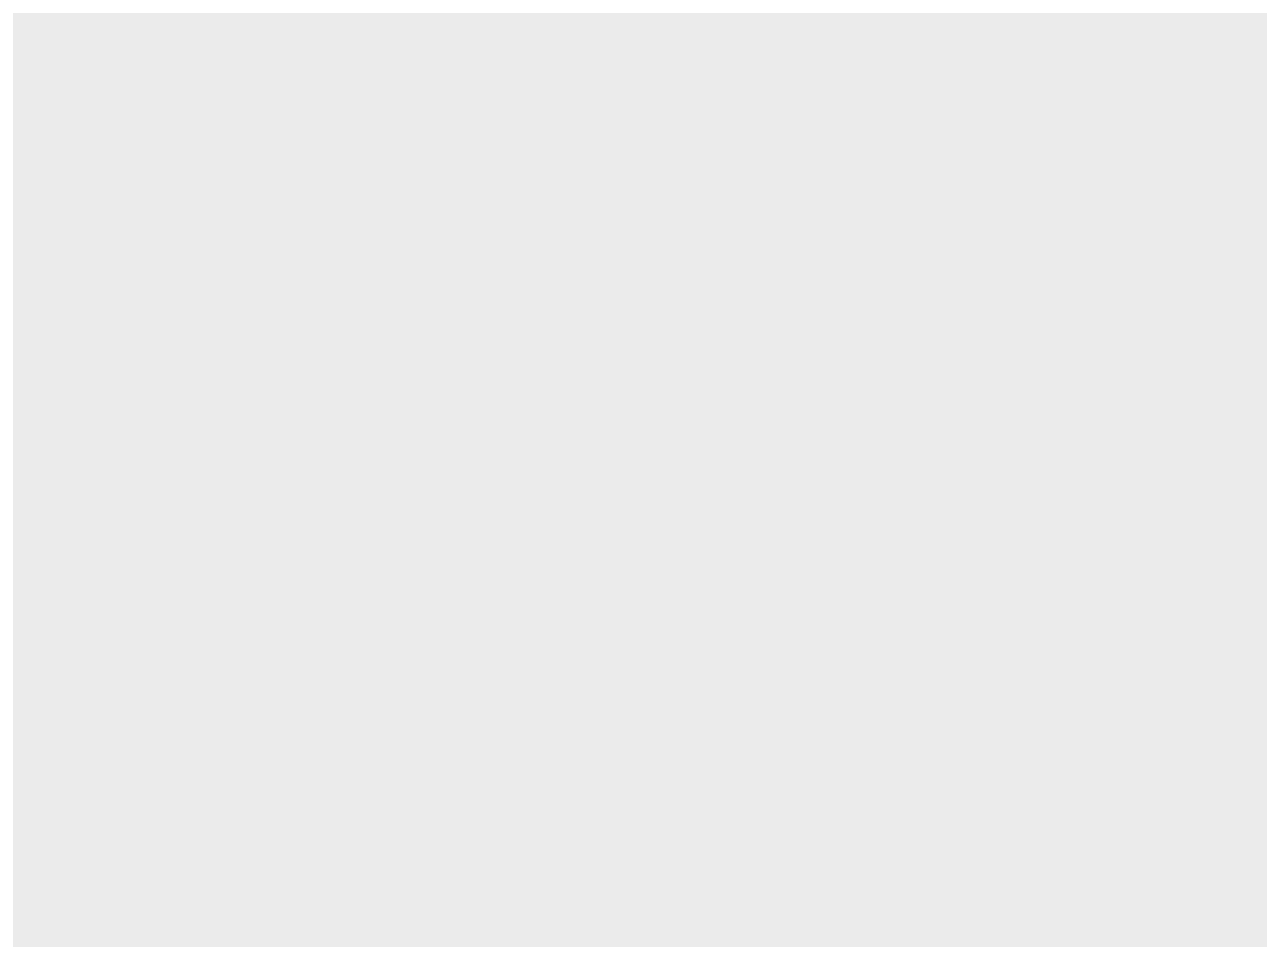

In [39]:
ggplot(dfMap)

----

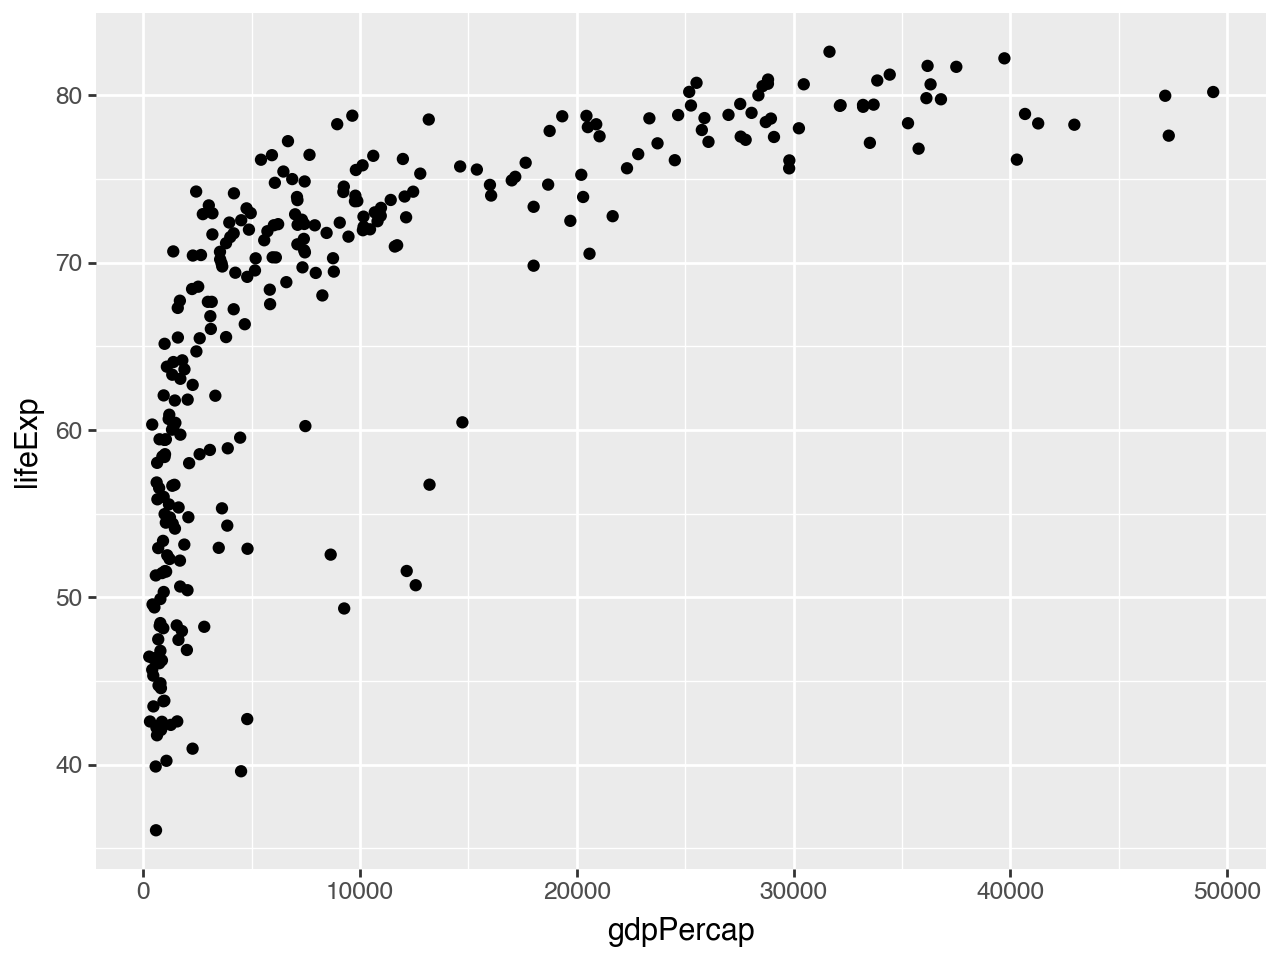

In [40]:
( 
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp'))
    + geom_point()
)

--------

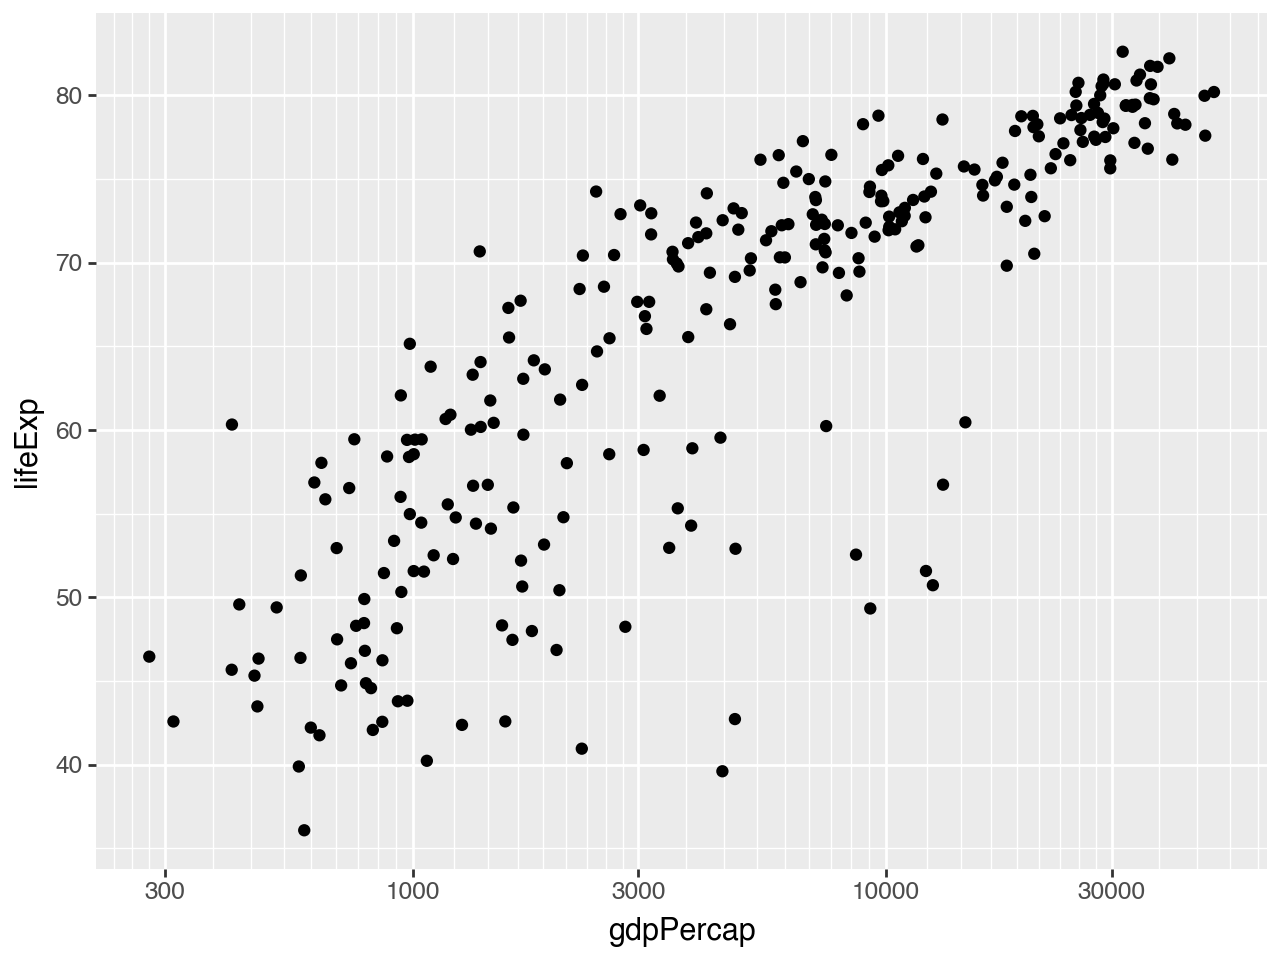

In [42]:
( 
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp'))
    + geom_point()
    + scale_x_log10()
)

----

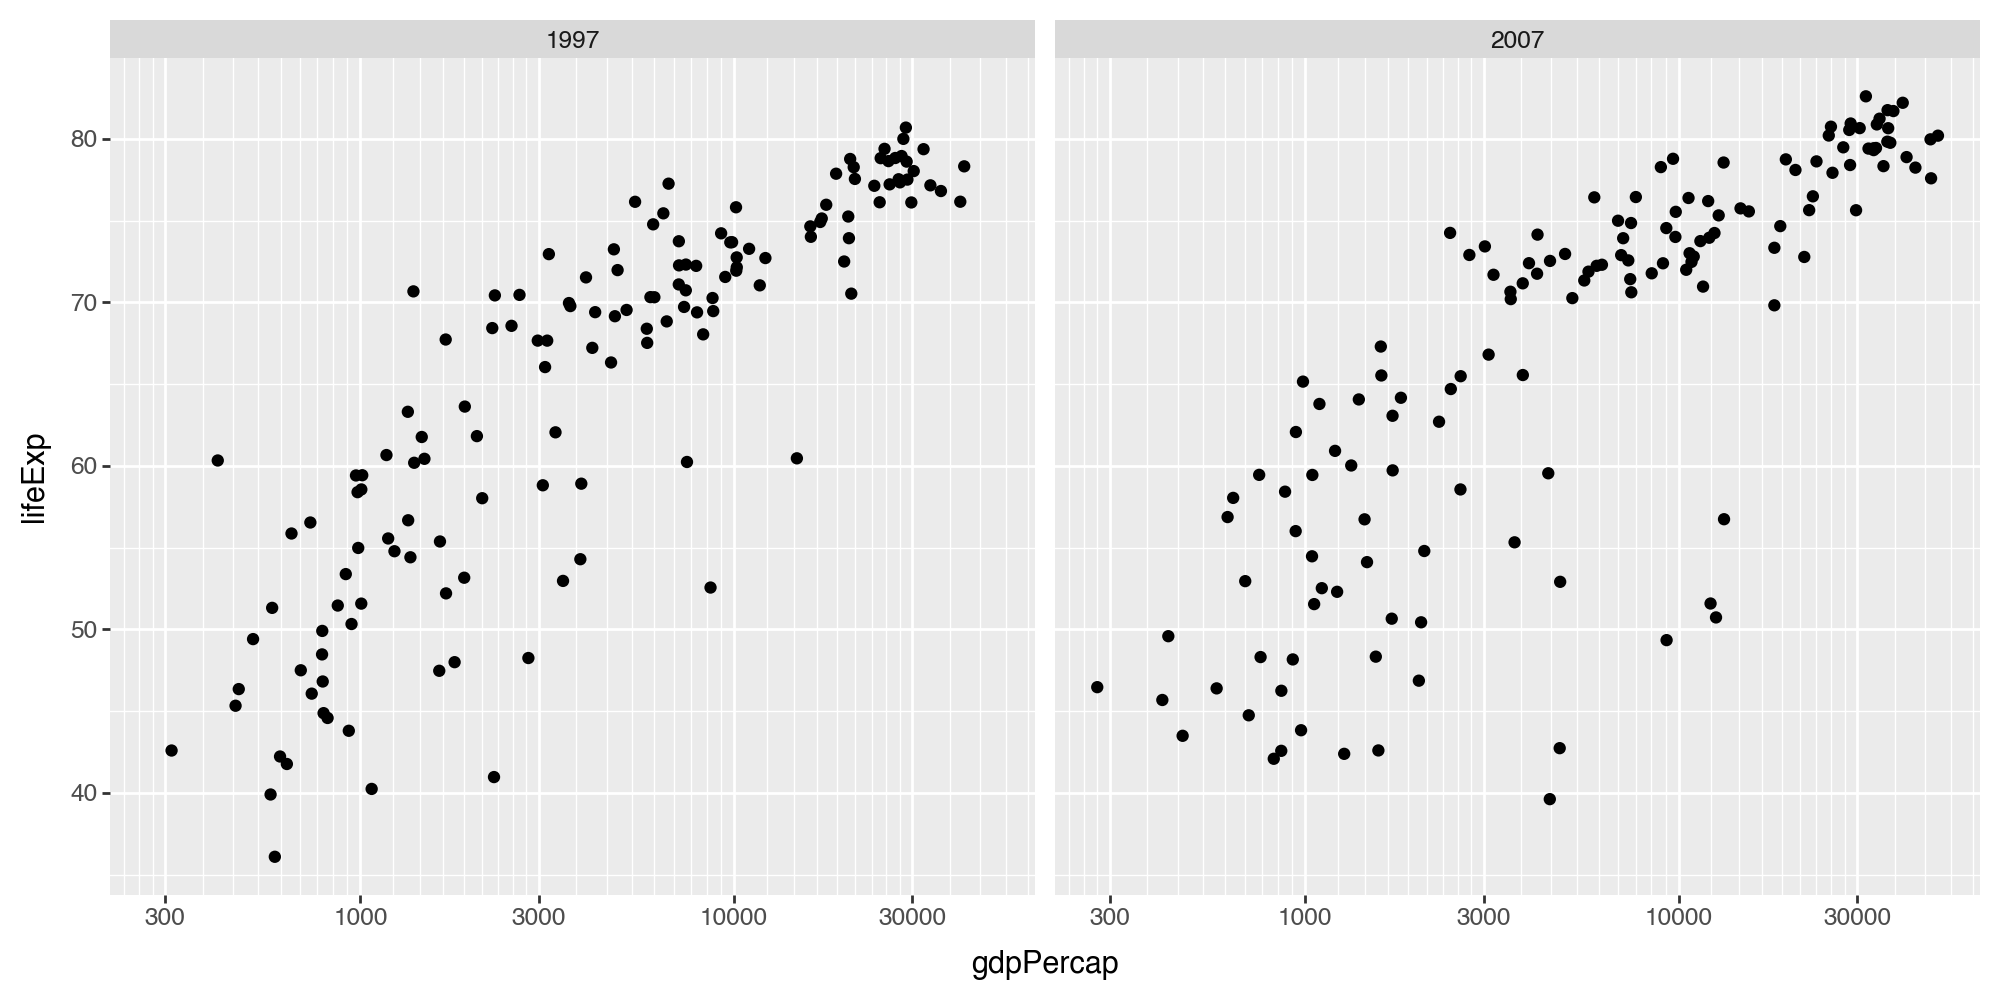

In [50]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp'))
    + geom_point()
    + scale_x_log10()
    + facet_grid('~year')
    + theme(figure_size=(10, 5))
)

-------

/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


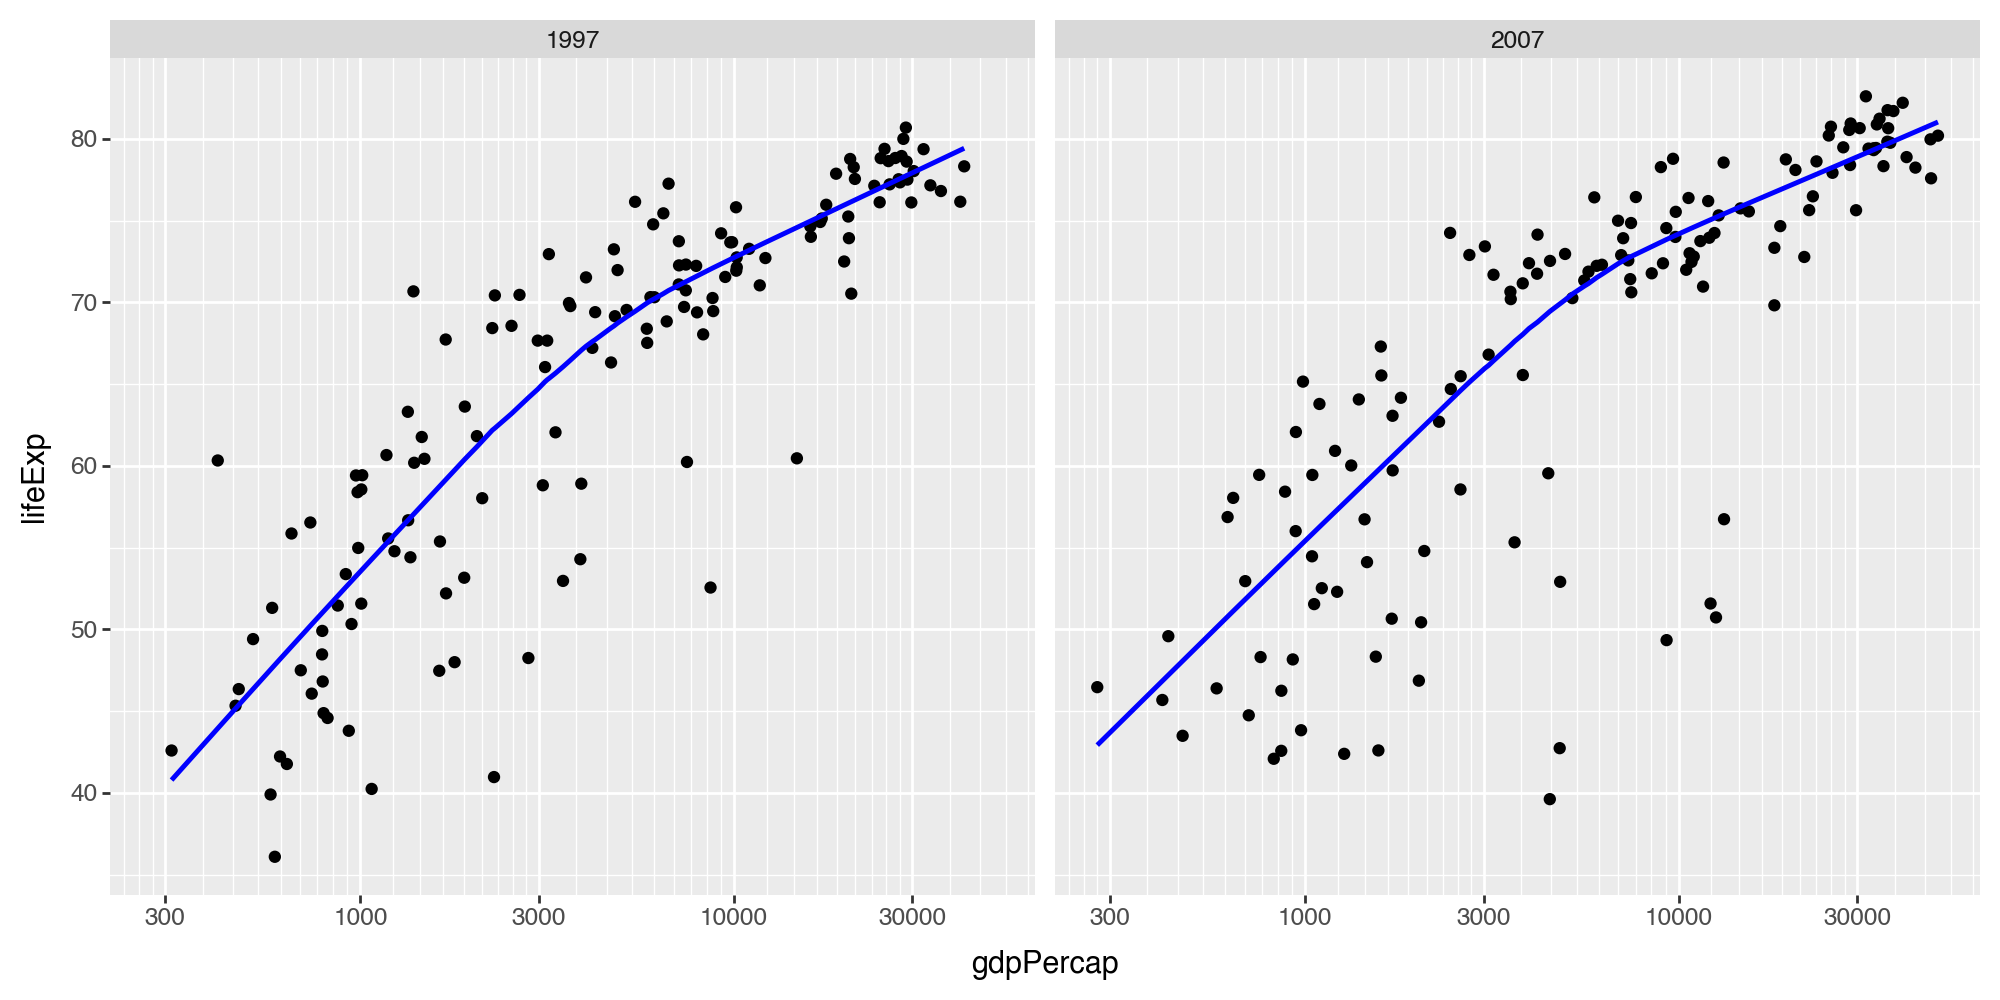

In [54]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp'))
    + geom_point()
    + scale_x_log10()
    + facet_grid('~year')
    + theme(figure_size= (10, 5))
    + stat_smooth(color = 'blue')
)

-------

We can easily map variables to different colors, sizes or shapes depending on the value of the specified variable using the aes() function

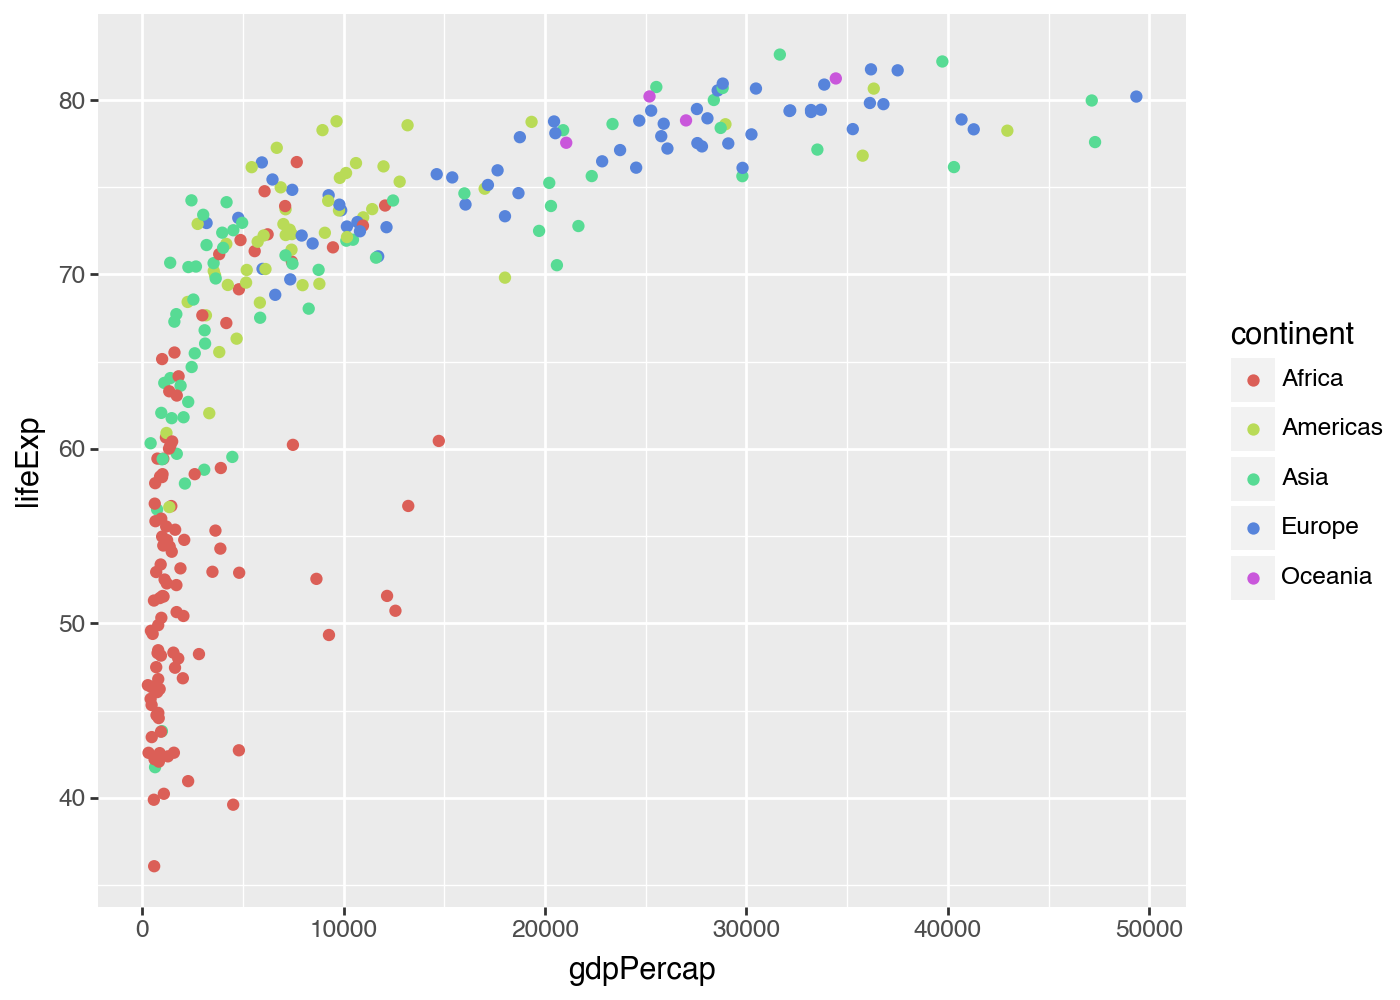

In [62]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp', color = 'continent'))
    + geom_point()
    + theme(figure_size= (7,5))
)

------

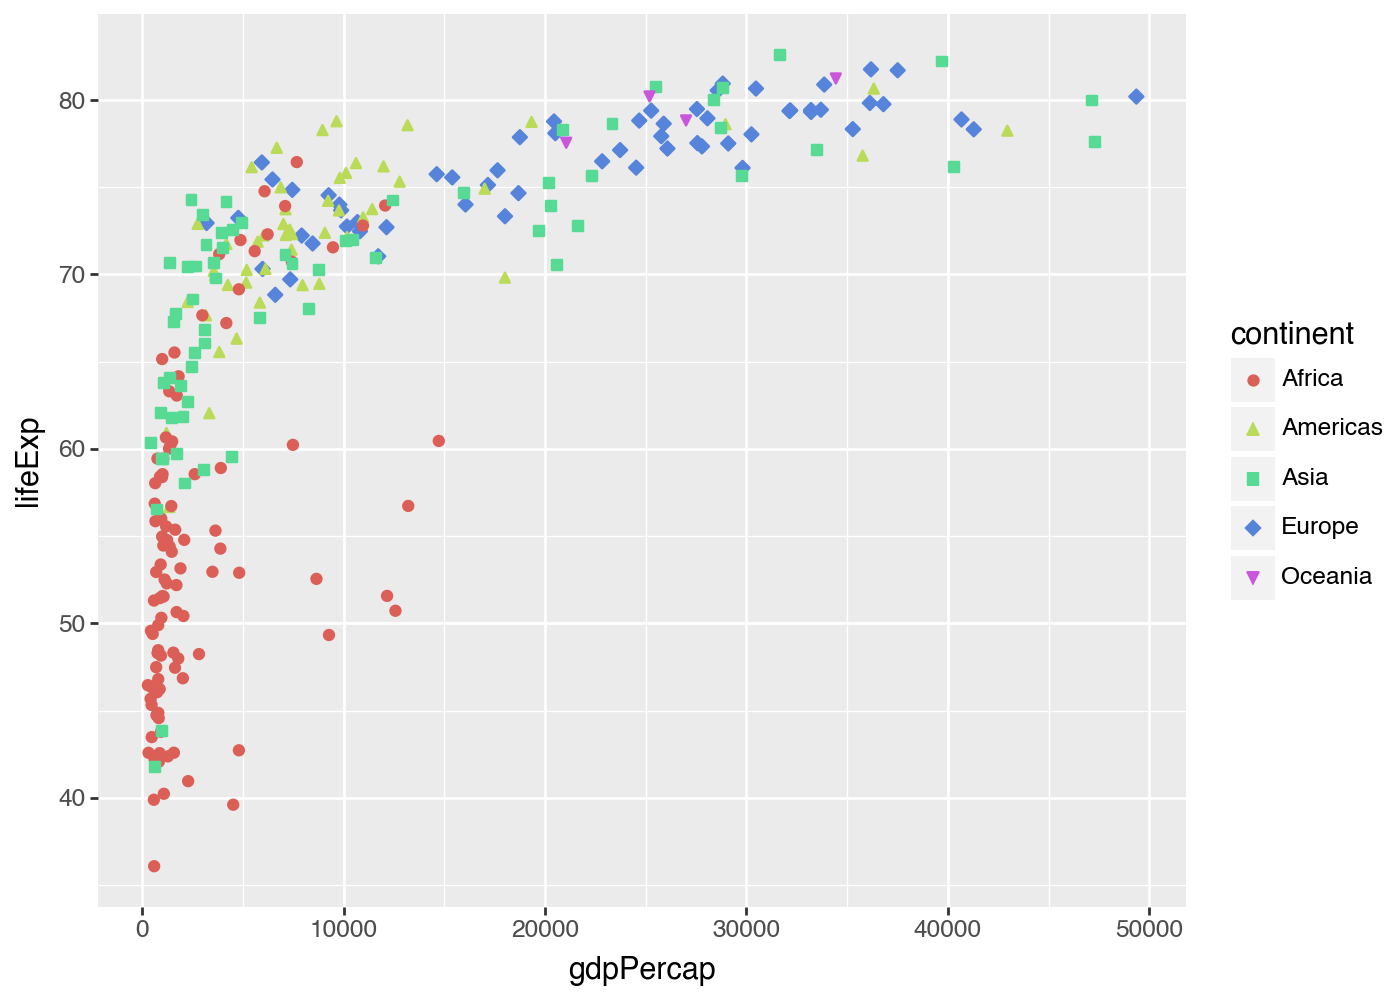

In [67]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp', shape = 'continent', color = 'continent'))
    + geom_point()
    + theme(figure_size= (7,5))
)

------

Additionally, we distinguish the population of each country by giving a size to the points
in the scatter plot:

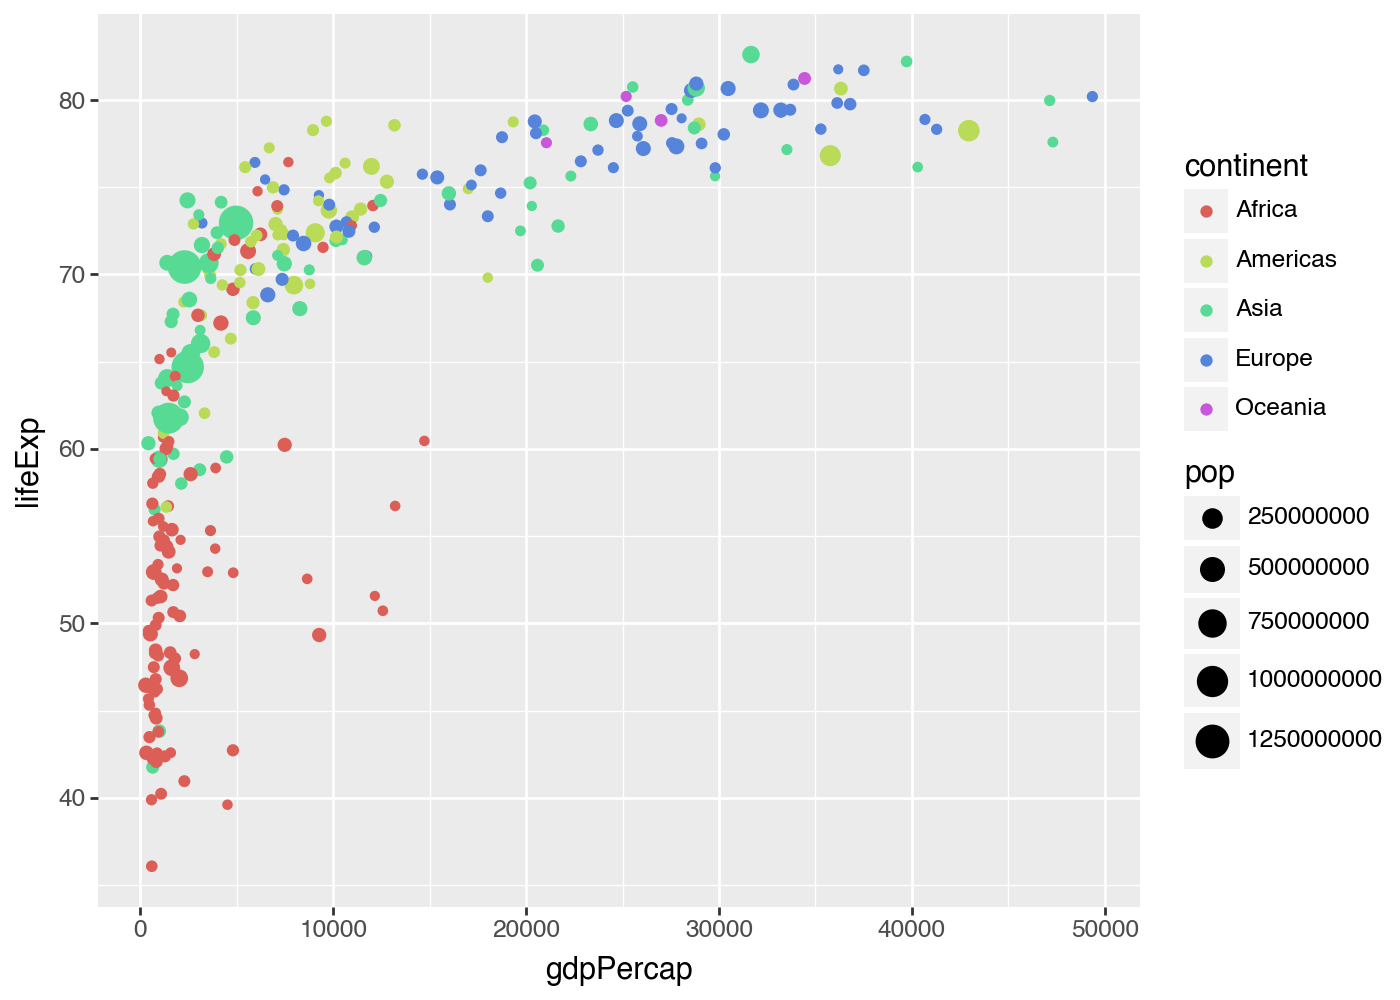

In [72]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp', color = 'continent', size = 'pop'))
    + geom_point()
    + theme(figure_size= (7,5))
)

----------

## Labels

labs()

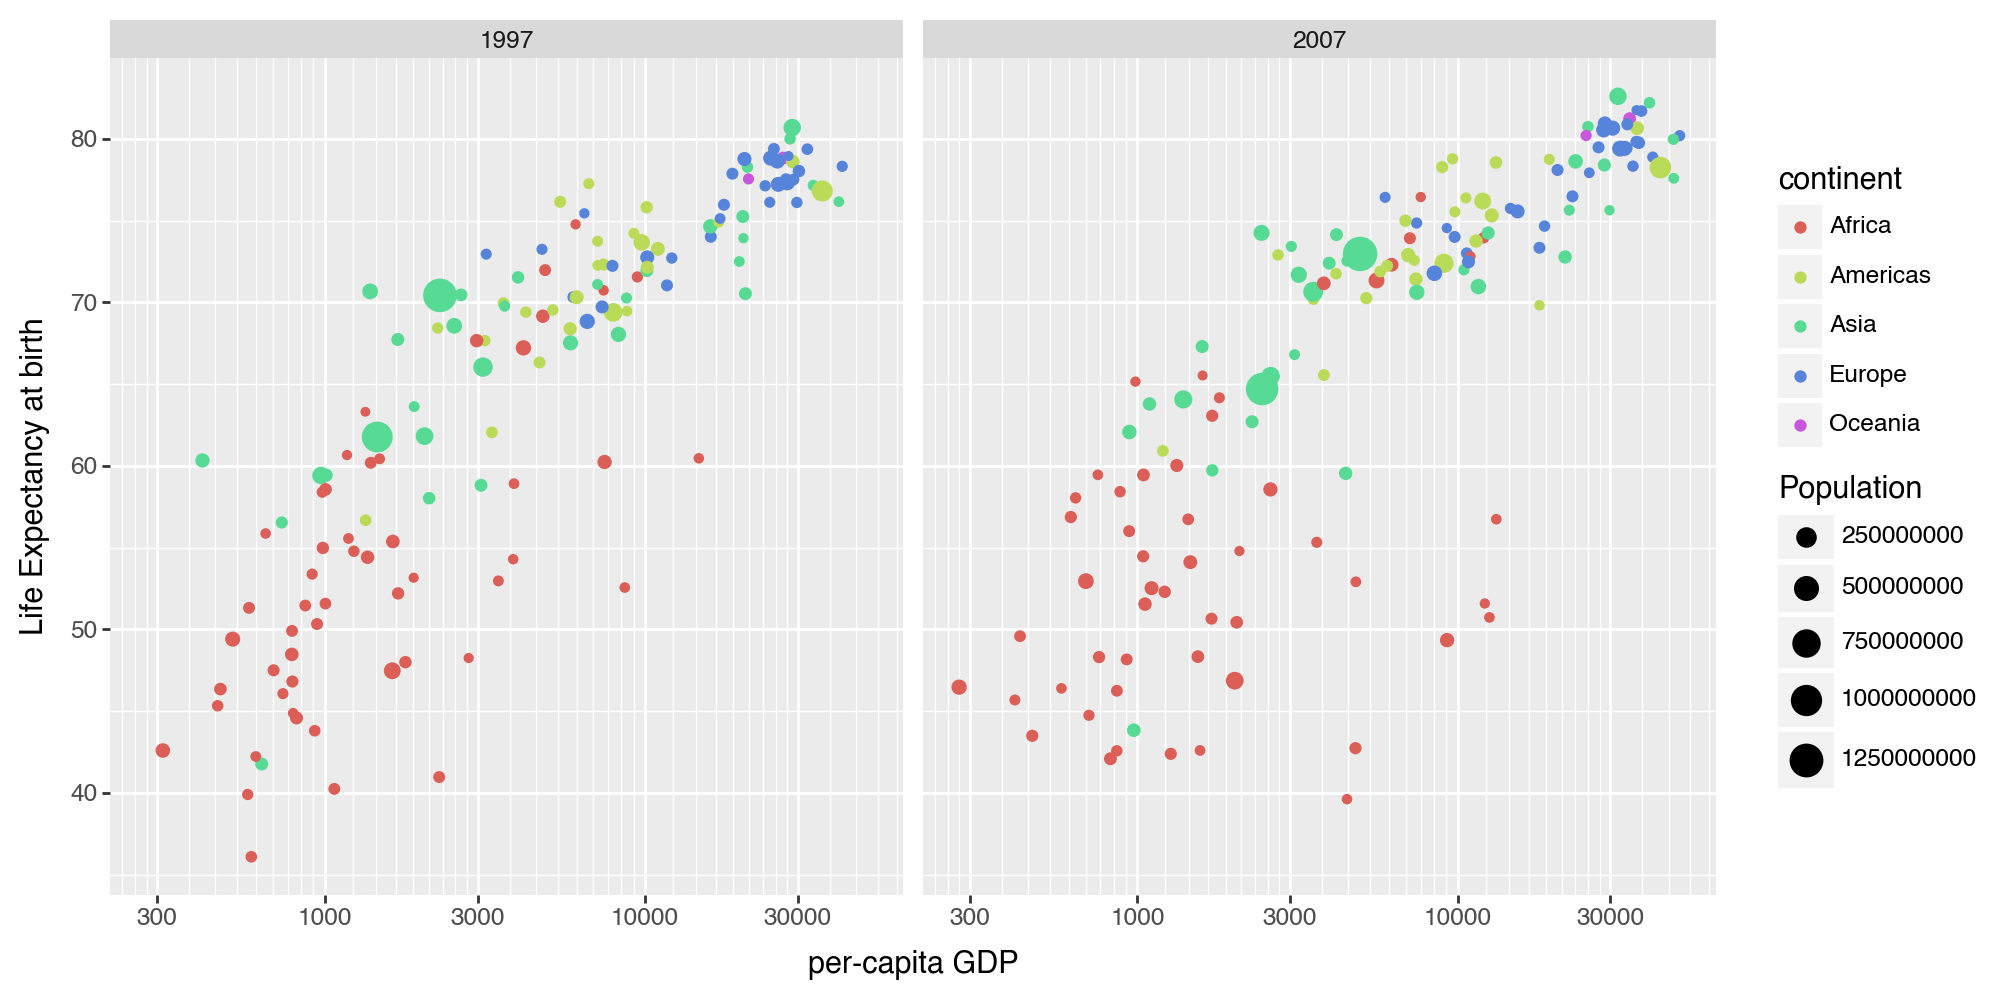

In [80]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp', color = 'continent', size = 'pop'))
    + geom_point()
    + theme(figure_size=(10,5))
    + labs(x = 'per-capita GDP', y = 'Life Expectancy at birth', size = 'Population')
    + facet_grid('~year')
    + scale_x_log10()
)

----------
## Themes

Some default settings can be stored in a so-called theme.

In [84]:
mysize = 9

mytheme = (
    theme(
        axis_title=element_text(size=mysize),
        axis_text=element_text(size=mysize),
        legend_title=element_text(size=mysize),
        legend_text=element_text(size=mysize)
        ) + theme_minimal(base_size=mysize)
    )

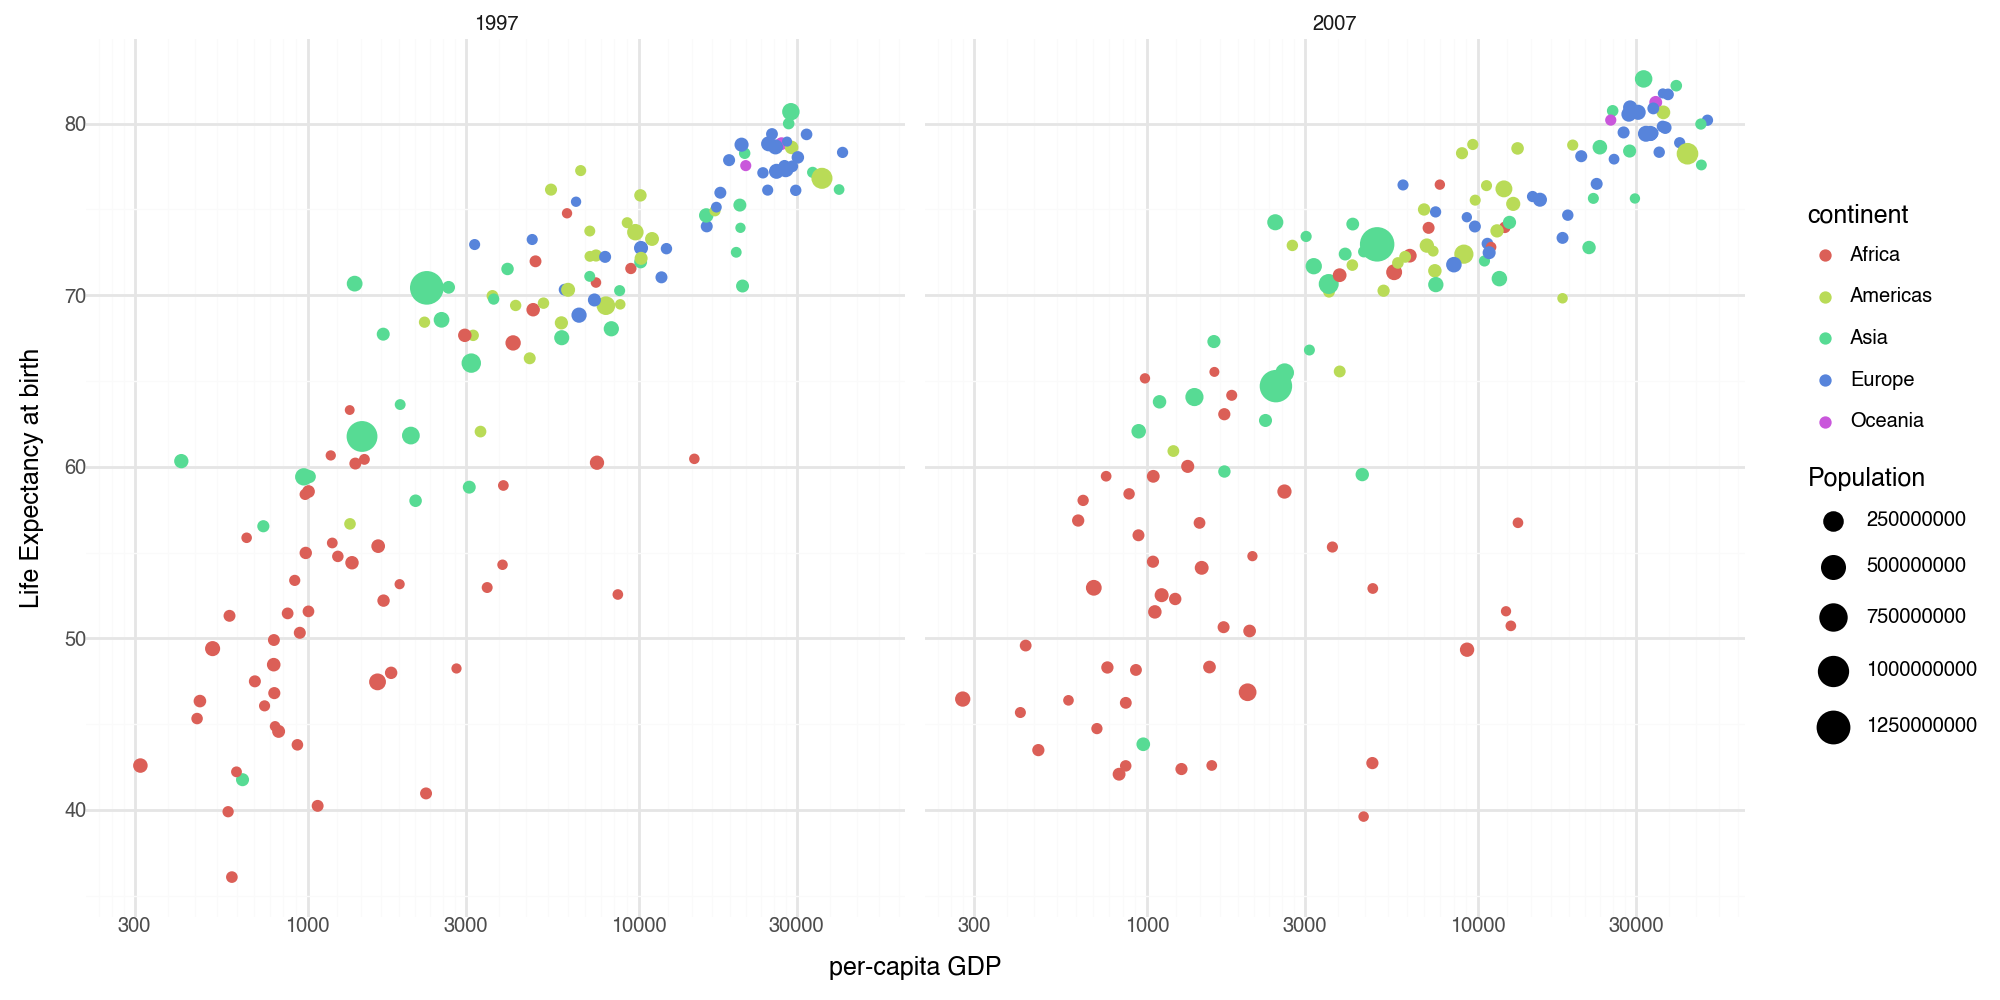

In [88]:
(
    ggplot(dfMap, aes(x = 'gdpPercap', y = 'lifeExp', color = 'continent', size = 'pop'))
    + geom_point()
    + labs(x = 'per-capita GDP', y = 'Life Expectancy at birth', size = 'Population')
    + facet_grid('~year')
    + scale_x_log10()
    + mytheme
    + theme(figure_size=(10,5))
)

------
# Continues Data

In [119]:
df = pd.read_csv('Datasets/human-development-index.csv')
df.rename(columns={
    'Human Development Index' : 'HDI',
    'World regions according to OWID': 'Regions'
}, inplace= True)

print(df['Regions'].unique())

[nan 'Asia' 'Europe' 'Africa' 'Oceania' 'North America' 'South America']


In [149]:
from plotnine import geom_histogram, geom_density, ggtitle

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 79 rows containing non-finite values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 79 rows containing non-finite values.


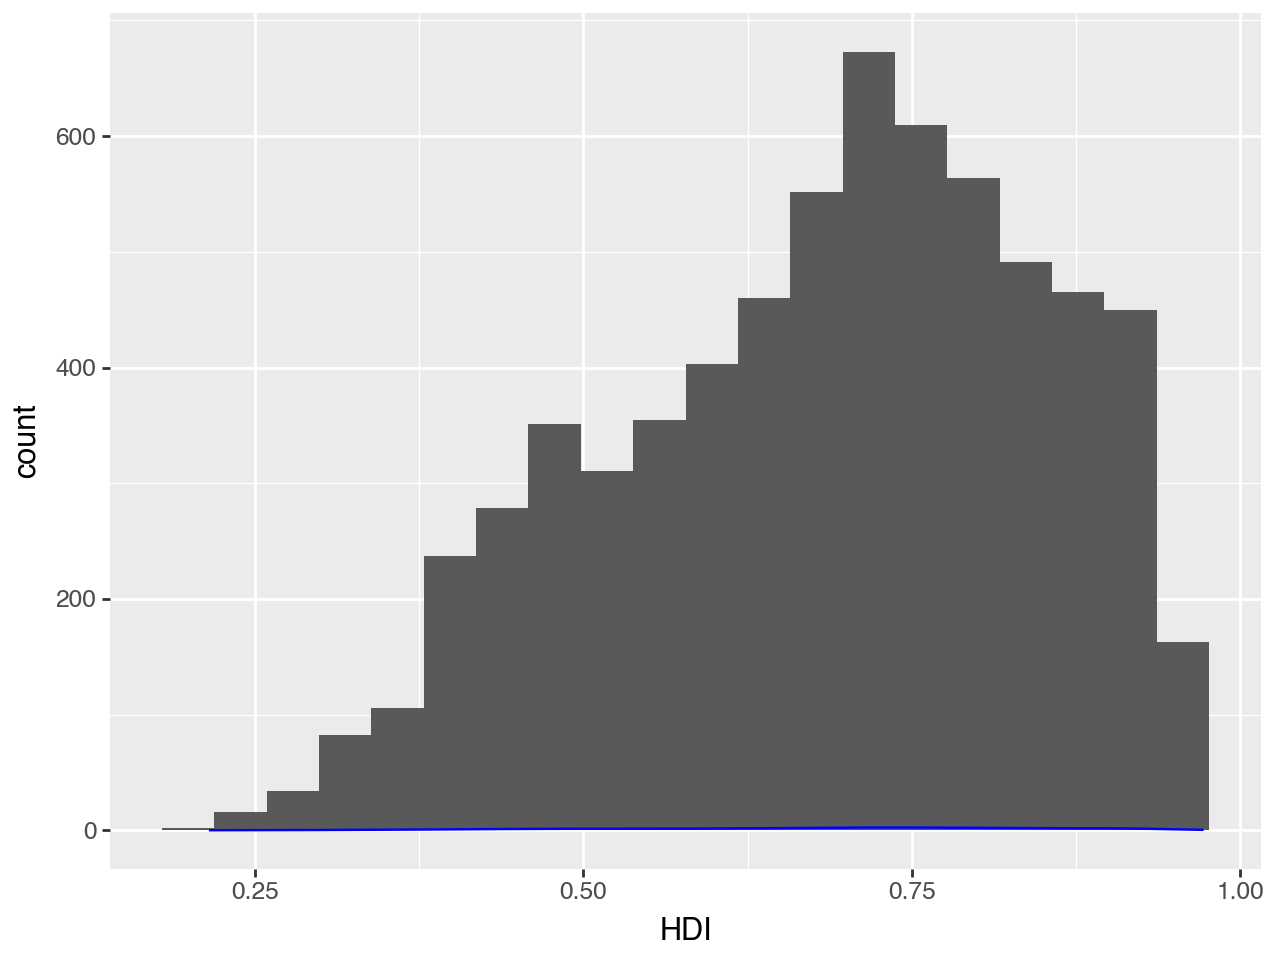

In [ ]:
(
    ggplot(df, aes(x = 'HDI'))
    + geom_histogram(bins = 20)
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 79 rows containing non-finite values.


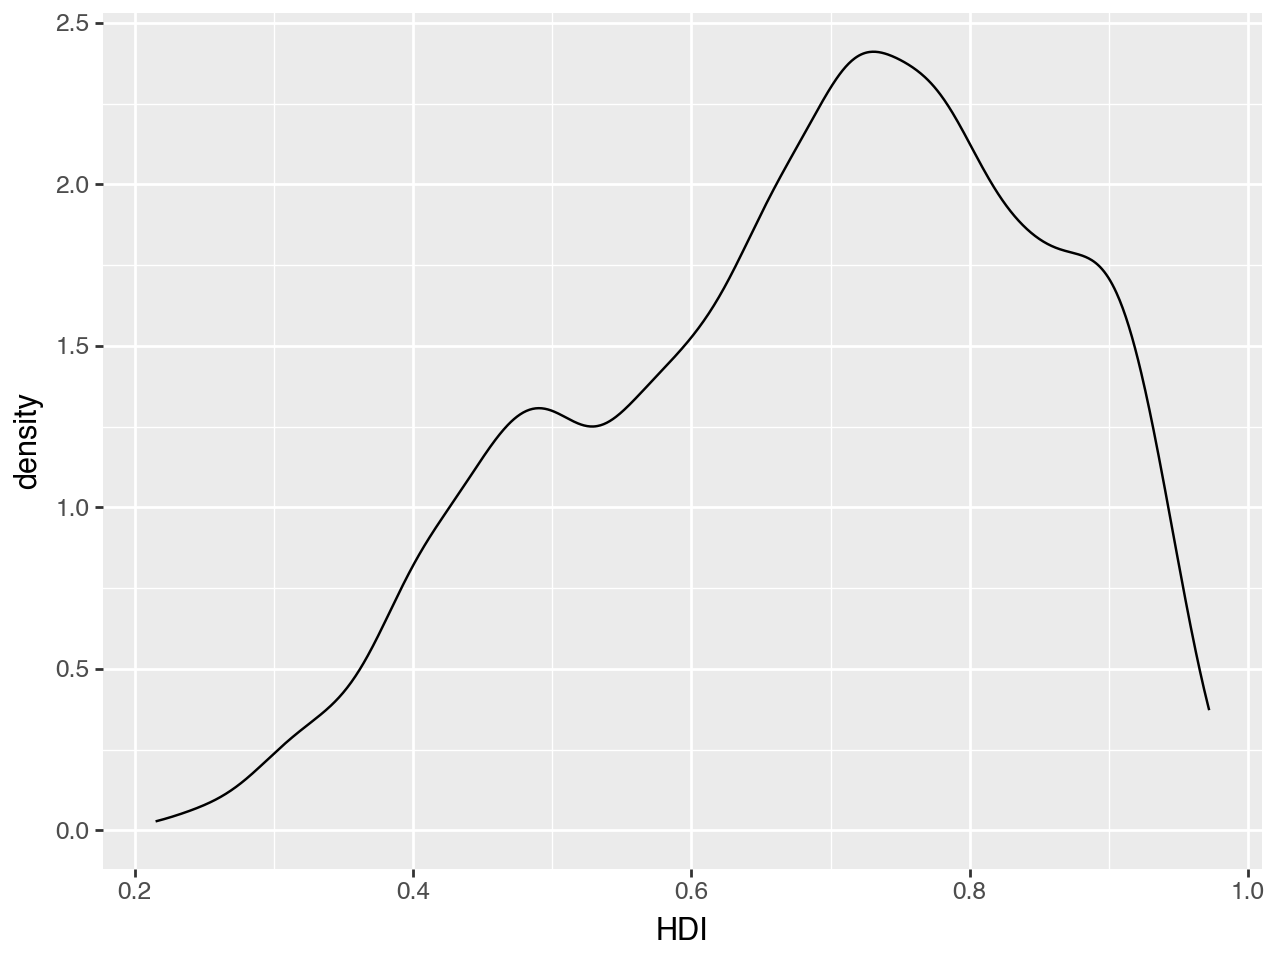

In [144]:
(
    ggplot(df, aes(x = 'HDI'))
    + geom_density()
)

## Bandwidth

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 79 rows containing non-finite values.


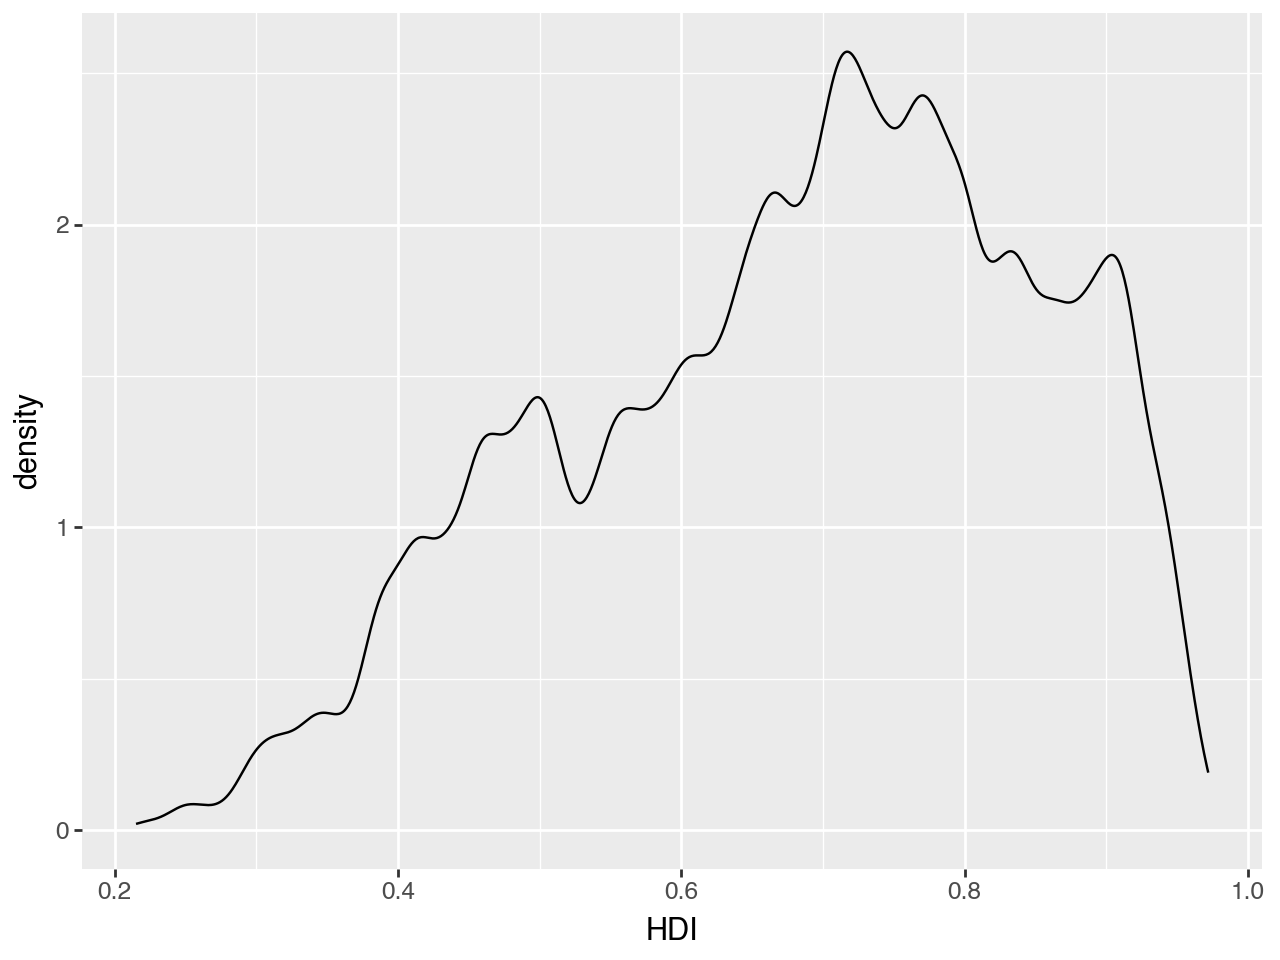

In [146]:
(
    ggplot(df, aes(x = 'HDI'))
    + geom_density(bw = 0.01)
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_density : Removed 79 rows containing non-finite values.


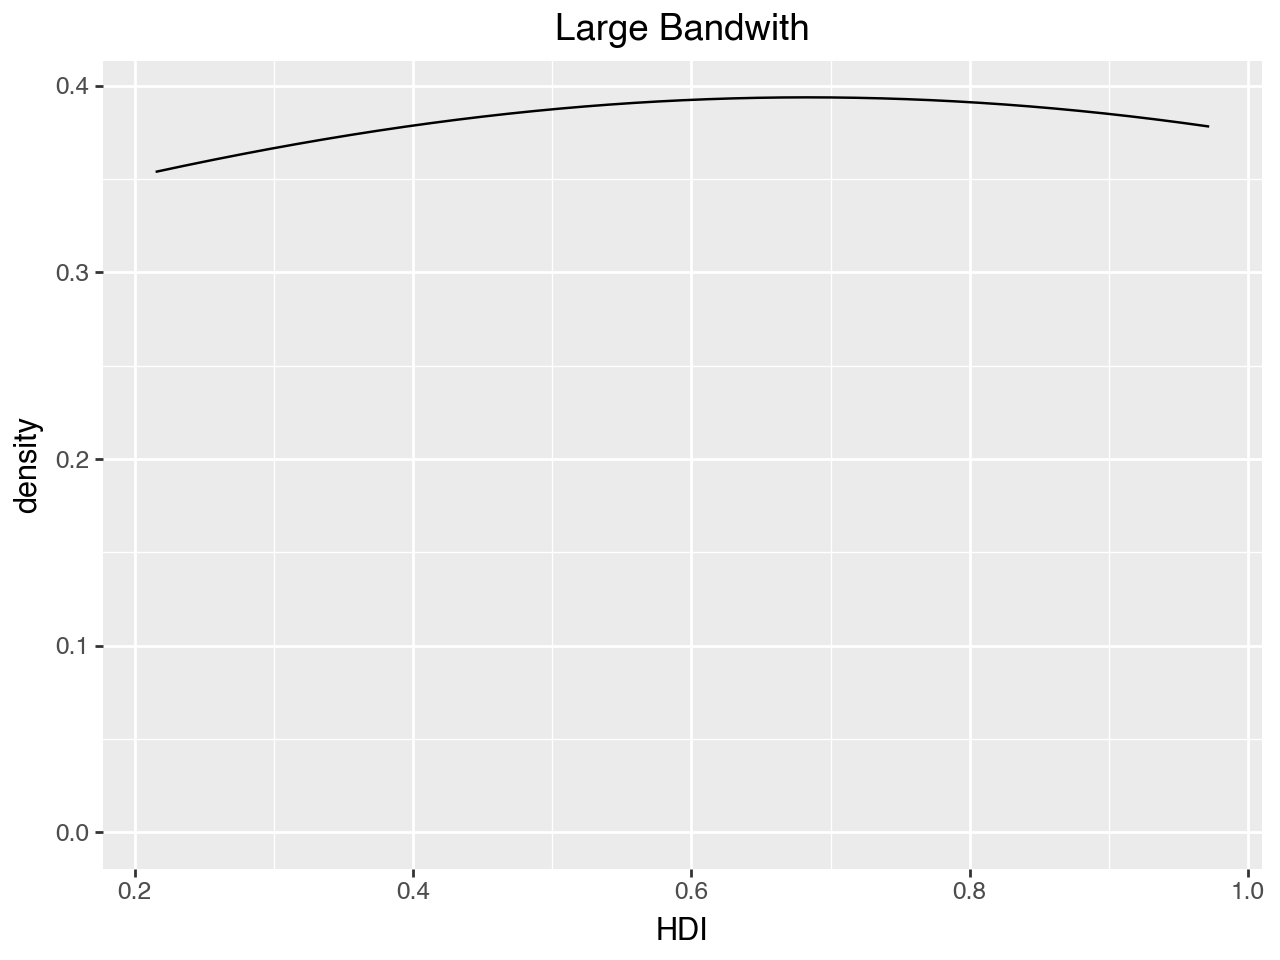

In [150]:
(
    ggplot(df, aes(x = 'HDI'))
    + geom_density(bw = 1)
    + ggtitle('Large Bandwith')
)

-------

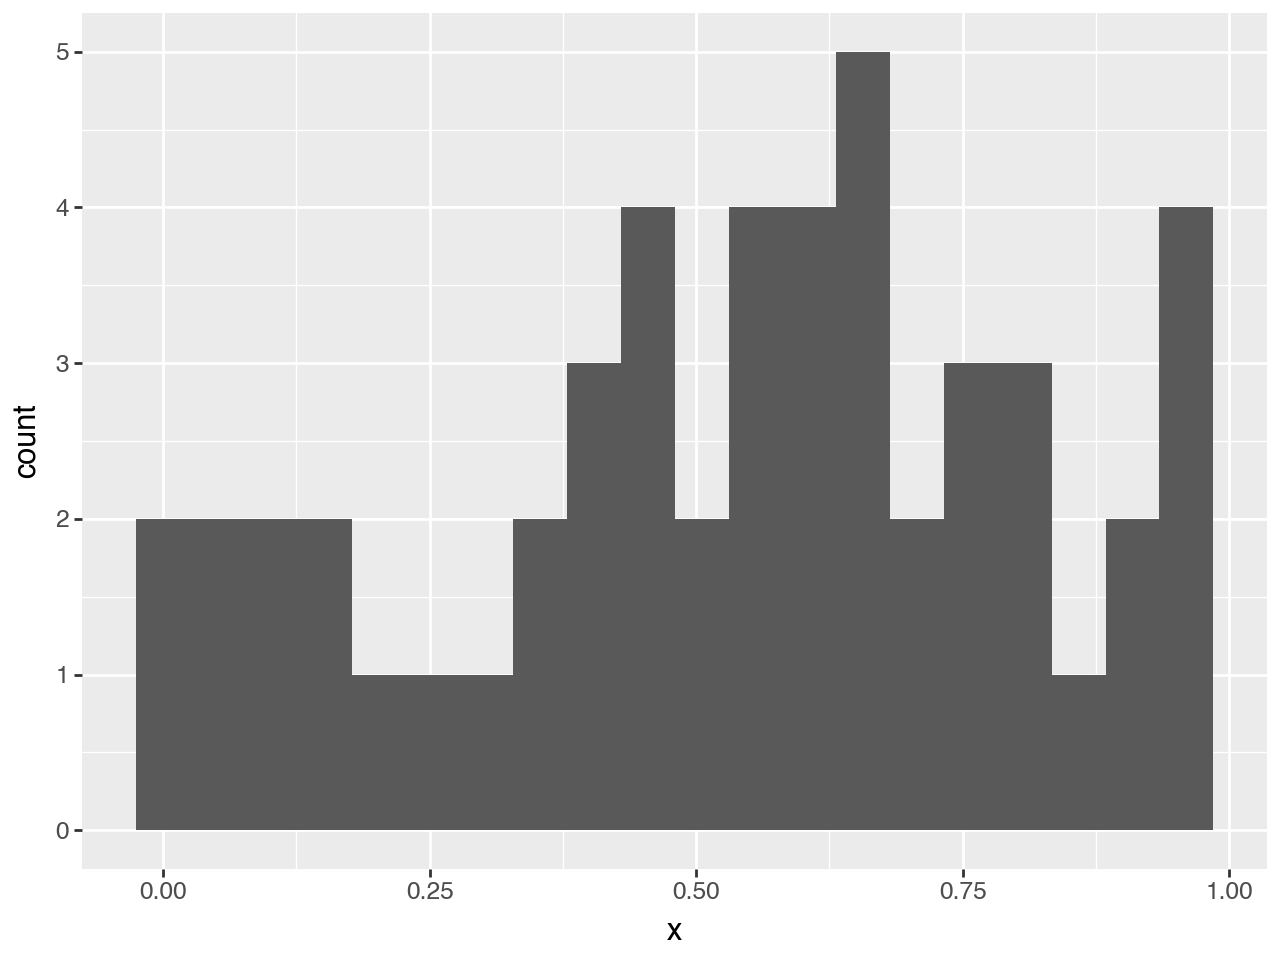

In [158]:
np.random.seed(0)

x = np.random.rand(50) # 50 independent draws for the uniform distribution

(
    ggplot( pd.DataFrame( {'x':x}), aes(x = 'x'))
    + geom_histogram(bins = 20)
)

Is it obvious that this data follows a uniform distribution ?

In [163]:
dec = np.quantile(x, np.arange(0, 1.1, 0.1))
print(dec)

[0.0187898  0.11515991 0.3052538  0.42095694 0.49770074 0.56823925
 0.62654971 0.68656357 0.78276835 0.89515536 0.97861834]


## Compare Emprical to Theoretical Quantities

In [170]:
from plotnine import xlim, ylim, geom_abline

The Q-Q plot scatter plots quantiles of two distributions against each other.

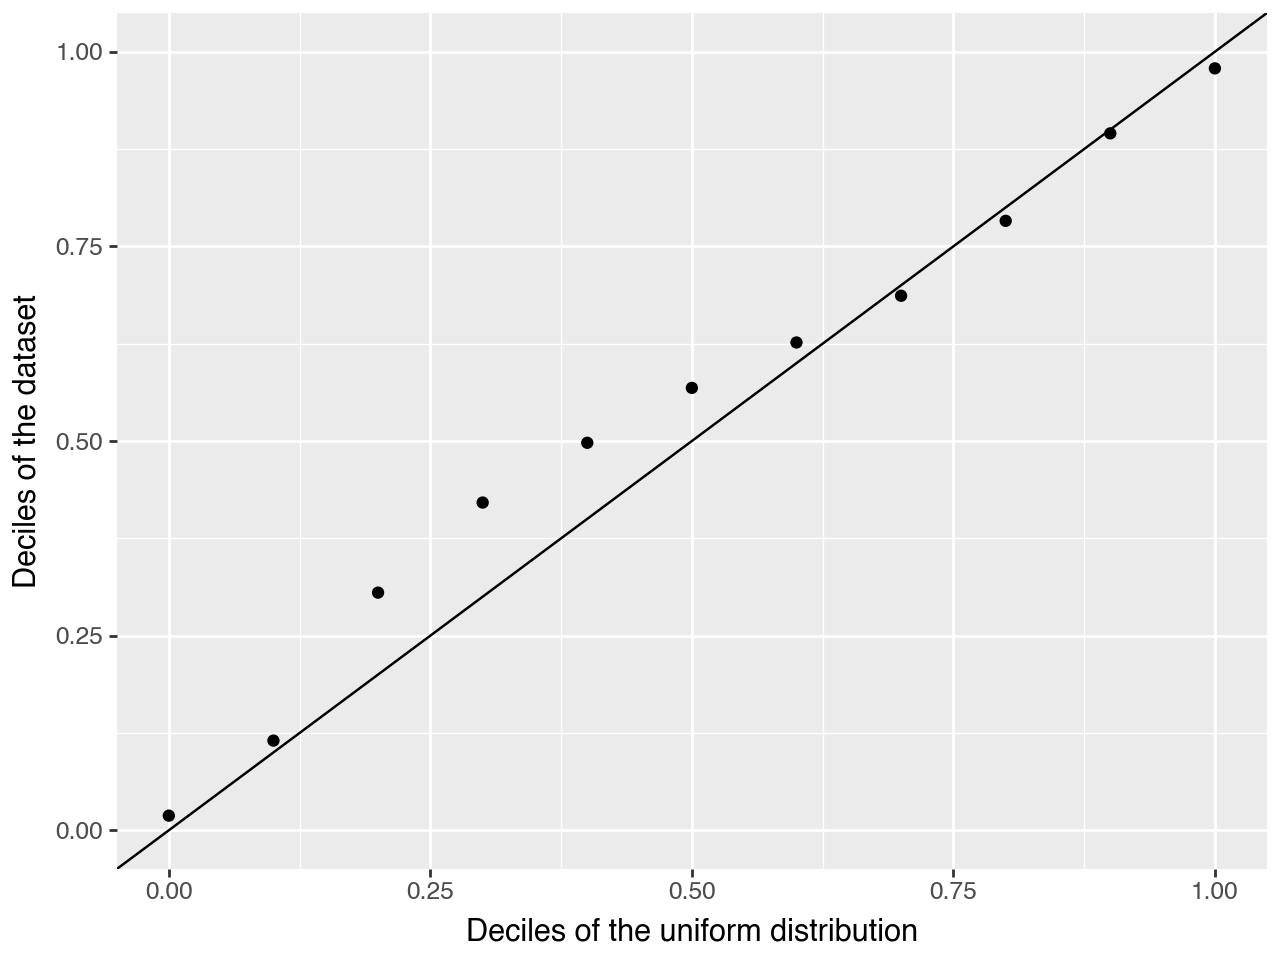

In [172]:
(
    ggplot(pd.DataFrame({ 'x': np.arange(0, 1.1, 0.1), 'y': dec }), aes(x = 'x', y = 'y'))
    + geom_point()
    + xlim(0,1)
    + ylim(0,1)
    + labs(x = 'Deciles of the uniform distribution', y = 'Deciles of the dataset')
    + geom_abline(intercept=0, slope=1)
)

-------

# Scipy (Scientific Python)

The package scipy (Scientific Python) provides statistical methods in Python. It uses
numpy underneath.

For every implemented distribution, scipy.stats offers the random draw (rvs), the
density (pdf), the cumulative disibtuion function (cdf), and its inverse (ppf) which
allows you get quantiles e.g.: norm.rvs(), uniform.rvs(), etc…

In [178]:
from scipy.stats import uniform

In [186]:
perc = list(np.arange(0, 1.1, 0.2))

uni = uniform.ppf(perc, loc = 0, scale = 2)
uni

array([0. , 0.4, 0.8, 1.2, 1.6, 2. ])